#Import labraiies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model #for model visualization

from warnings import filterwarnings
filterwarnings('ignore')



# Read dataset into DataFrame

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/graduation project/autism_screening.csv')
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7.0,18 and more,Self,YES
700,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3.0,18 and more,Parent,NO
701,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7.0,18 and more,?,YES
702,1,0,0,1,1,0,1,0,1,1,...,m,South Asian,no,no,Pakistan,no,6.0,18 and more,Self,NO


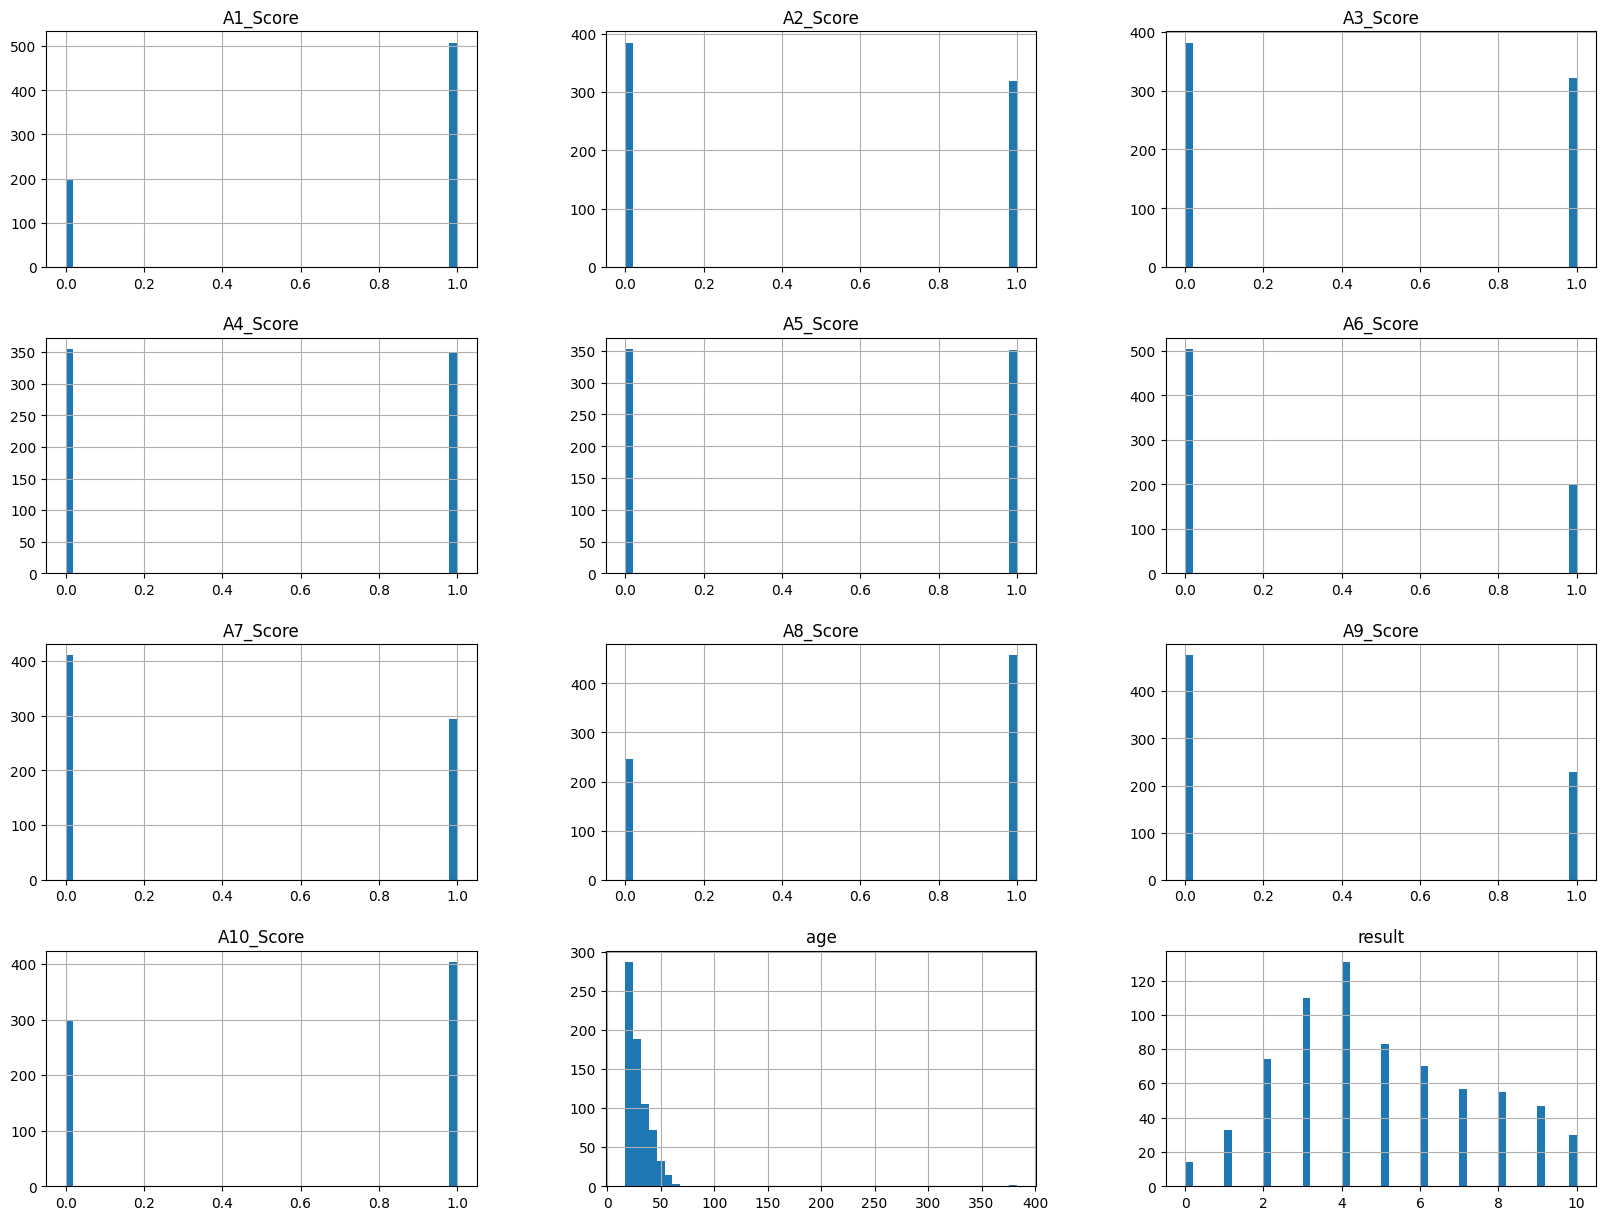

In [ ]:
df.hist(bins=50, figsize=(20,15)) # show histogram 20 = width ,  15 = height
plt.show()

In [ ]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [ ]:
print("Number of Rows:",df.shape[0])
print("Number of Features:",df.shape[1])

Number of Rows: 704
Number of Features: 21


In [ ]:
df.info()#gender have 2 nulls values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jundice          704 non-null    object 
 14  austim           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

***
**Numirical features:**


*   A1-A10
*   age
*   result


**categorical features:**



* gender
* ethnicity
* jundice
* austim
* contry_of_res
* used_app_before
* age_desc
* relation
* Class/ASD




In [ ]:
df.isnull().sum()

,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


In [ ]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,702.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,29.698006,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,16.507465,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,27.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,383.000000,10.000000


In [ ]:
df['age'].value_counts()

,count
age,
21.0,49
20.0,46
23.0,37
22.0,37
19.0,35
24.0,34
27.0,31
18.0,31
30.0,30




# preprocessing



<Axes: ylabel='age'>

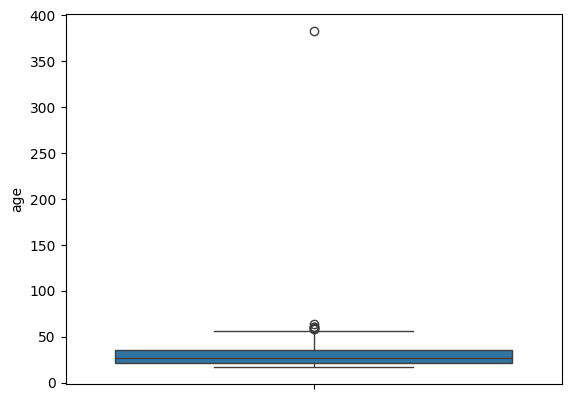

In [ ]:
sns.boxplot(df['age'])

In [ ]:
df = df.drop(df[df['age'] == 383].index)

In [ ]:
#check
df['age'].value_counts()

,count
age,
21.0,49
20.0,46
23.0,37
22.0,37
19.0,35
24.0,34
18.0,31
27.0,31
30.0,30


<Axes: ylabel='age'>

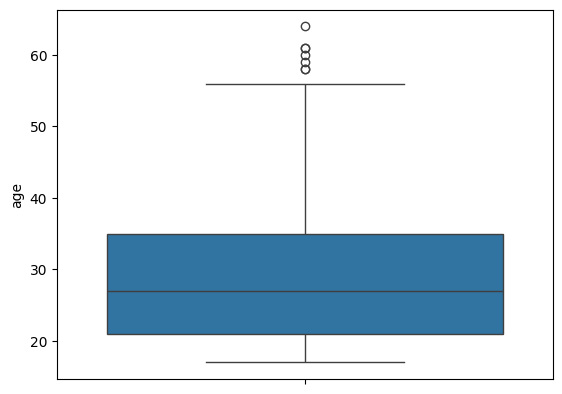

In [ ]:
sns.boxplot(df['age'])

In [ ]:
#missing values
df['age'].isnull().sum()

2

In [ ]:
#fill the missing values with the mean
df['age'] = df['age'].fillna(round(df['age'].mean()))

In [ ]:
df['age'].isnull().sum()

0

**Categorical Data**

In [ ]:
df['gender'].value_counts()

,count
gender,
m,367
f,336


In [ ]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,233
Asian,123
?,95
Middle Eastern,92
Black,43
South Asian,36
Others,30
Latino,20
Hispanic,13


In [ ]:
df['ethnicity'] = df['ethnicity'].replace(['?','others'], 'Others')

In [ ]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,233
Others,126
Asian,123
Middle Eastern,92
Black,43
South Asian,36
Latino,20
Hispanic,13
Pasifika,11


In [ ]:
df['jundice'].value_counts()

,count
jundice,
no,634
yes,69


In [ ]:
df['austim'].value_counts()

,count
austim,
no,612
yes,91


In [ ]:
df['contry_of_res'].value_counts()

,count
contry_of_res,
United States,113
United Arab Emirates,82
India,81
New Zealand,80
United Kingdom,77
...,...
China,1
Chile,1
Lebanon,1


In [ ]:
df['used_app_before'].value_counts()

,count
used_app_before,
no,691
yes,12


In [ ]:
df['age_desc'].value_counts()

,count
age_desc,
18 and more,703


In [ ]:
df['relation'].value_counts()

,count
relation,
Self,521
?,95
Parent,50
Relative,28
Others,5
Health care professional,4


In [ ]:
df['relation'] = df['relation'].replace('?', 'Others')

In [ ]:
df['relation'].value_counts()

,count
relation,
Self,521
Others,100
Parent,50
Relative,28
Health care professional,4


In [ ]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
NO,514
YES,189



# Data Visualization

In [ ]:
fig = px.histogram(df, x='Class/ASD')

fig.update_layout(title_text='<b>Count of Autistic and Non-Autistic Patients</b>', title_x=0.5)

fig.show()

In [ ]:
#average age of autistic and non-autistic patients
fig = px.bar(df.groupby('Class/ASD', as_index=False).agg({'age':'mean'}),
             x='Class/ASD',
             y='age',
             color='Class/ASD',
             title='Average Age of Autistic and Non-Autistic Patients')


fig.update_layout(title_text='<b>Average Age of Autistic and Non-Autistic Patients</b>', title_x=0.5)
fig.show()

In [ ]:
#using plotly to visualize the count of the gender
fig = px.histogram(df, x='gender')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Males and Females </b>', title_x=0.5)

# Show the plot
fig.show()



In [ ]:
#using plotly to visualize the count of the males and females for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'gender']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='gender',
             title='Count of Males and Females of Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Males and Females of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [ ]:
# Count of Autistic Patients in Different Countries
filtered_df = df[df['Class/ASD'] == "YES"]

# Create a histogram
fig = px.histogram(filtered_df, x='contry_of_res')

# Update layout to center the title and set the category order
fig.update_layout(
    title_text='<b>Count of Autistic Patients in Different Countries</b>',
    title_x=0.5,
    xaxis=dict(categoryorder='total descending')
)

# Show the plot
fig.show()

In [ ]:
#using plotly to visualize the count of age_desc for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'age_desc']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='age_desc',
             title='Count of People over 18 for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People over 18 for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [ ]:
#using plotly to visualize 'jundice' with pie chart
fig = px.pie(df, names='jundice')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People with Jaundice</b>', title_x=0.5)

# Show the plot
fig.show()

In [ ]:
#using plotly to visualize the count of people with jundice for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'jundice']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='jundice',
             title='Count of people with jundice for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of people with jundice for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [ ]:
#using plotly to visualize 'used_app_before' with pie chart
fig = px.pie(df, names='used_app_before')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People who used the screening App before</b>', title_x=0.5)

# Show the plot
fig.show()

In [ ]:
#using plotly to visualize used_app_before for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'used_app_before']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='used_app_before',
             title='Count of People who used the screening App before for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People who used the screening App before for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

# Drop Unneeded Column

In [ ]:
#drop the 'age_desc' column
df = df.drop('age_desc', axis=1)

In [ ]:
df["used_app_before"].value_counts()

,count
used_app_before,
no,691
yes,12


In [ ]:
df = df.drop('used_app_before', axis=1)
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,6.0,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,5.0,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,8.0,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,6.0,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40.0,f,Others,no,no,Egypt,2.0,Others,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,25.0,f,White-European,no,no,Russia,7.0,Self,YES
700,1,0,0,0,0,0,0,1,0,1,34.0,m,Hispanic,no,no,Mexico,3.0,Parent,NO
701,1,0,1,1,1,0,1,1,0,1,24.0,f,Others,no,no,Russia,7.0,Others,YES
702,1,0,0,1,1,0,1,0,1,1,35.0,m,South Asian,no,no,Pakistan,6.0,Self,NO


In [ ]:
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,6.0,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,5.0,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,8.0,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,6.0,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40.0,f,Others,no,no,Egypt,2.0,Others,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,25.0,f,White-European,no,no,Russia,7.0,Self,YES
700,1,0,0,0,0,0,0,1,0,1,34.0,m,Hispanic,no,no,Mexico,3.0,Parent,NO
701,1,0,1,1,1,0,1,1,0,1,24.0,f,Others,no,no,Russia,7.0,Others,YES
702,1,0,0,1,1,0,1,0,1,1,35.0,m,South Asian,no,no,Pakistan,6.0,Self,NO


#Splitting Features from Target

In [ ]:
X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']

# **<font color = #208AAE>Handling Categorical Features</font>**

- 'gender'
- 'ethnicity'
- 'jundice'
- 'austim'
- 'contry_of_res'
- 'used_app_before'
- 'relation'
- 'Class/ASD'

In [ ]:
# Columns to apply label encoding
cols_to_encode = ['gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'relation']

# Apply label encoding to X
label_encoder_X = LabelEncoder()
for col in cols_to_encode:
    X[col] = label_encoder_X.fit_transform(X[col])

# Apply label encoding to y
label_encoder_y = LabelEncoder()
y = label_encoder_y.fit_transform(y)

In [ ]:
X.head(10)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,result,relation
0,1,1,1,1,0,0,1,1,0,0,26.0,0,9,0,0,64,6.0,4
1,1,1,0,1,0,0,0,1,0,1,24.0,1,3,0,1,13,5.0,4
2,1,1,0,1,1,0,1,1,1,1,27.0,1,3,1,1,56,8.0,2
3,1,1,0,1,0,0,1,1,0,1,35.0,0,9,0,1,64,6.0,4
4,1,0,0,0,0,0,0,1,0,0,40.0,0,5,0,0,22,2.0,1
5,1,1,1,1,1,0,1,1,1,1,36.0,1,5,1,0,64,9.0,4
6,0,1,0,0,0,0,0,1,0,0,17.0,0,1,0,0,64,2.0,4
7,1,1,1,1,0,0,0,0,1,0,64.0,1,9,0,0,43,5.0,2
8,1,1,0,0,1,0,0,1,1,1,29.0,1,9,0,0,64,6.0,4
9,1,1,1,1,0,1,1,1,1,0,17.0,1,0,1,1,9,8.0,0


In [ ]:
y[:5]

array([0, 0, 1, 0, 0])

# Splitting data into Train Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of Y_train is: {y_train.shape}\n")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of Y_test is: {y_test.shape}")

Shape of X_train is: (562, 18)
Shape of Y_train is: (562,)

Shape of X_test is: (141, 18)
Shape of Y_test is: (141,)



# <p style="background-color:#D2D4C8;font-family:ui-rounded;color:#5E4955;font-size:120%;text-align:center;border-radius:10px 10px;">Building ANN Model</p>

### **<font color = "purple">Model Structure</font>**

In [ ]:
model = Sequential([
        Dense(10, activation='relu', input_dim=18),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
])

### **<font color = "purple">Model Compiling</font>**

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### **<font color = "purple">Model Summary</font>**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             190 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              88 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 287 (1.12 KB)

 Trainable params: 287 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

### **<font color = "purple">Model Visualization</font>**

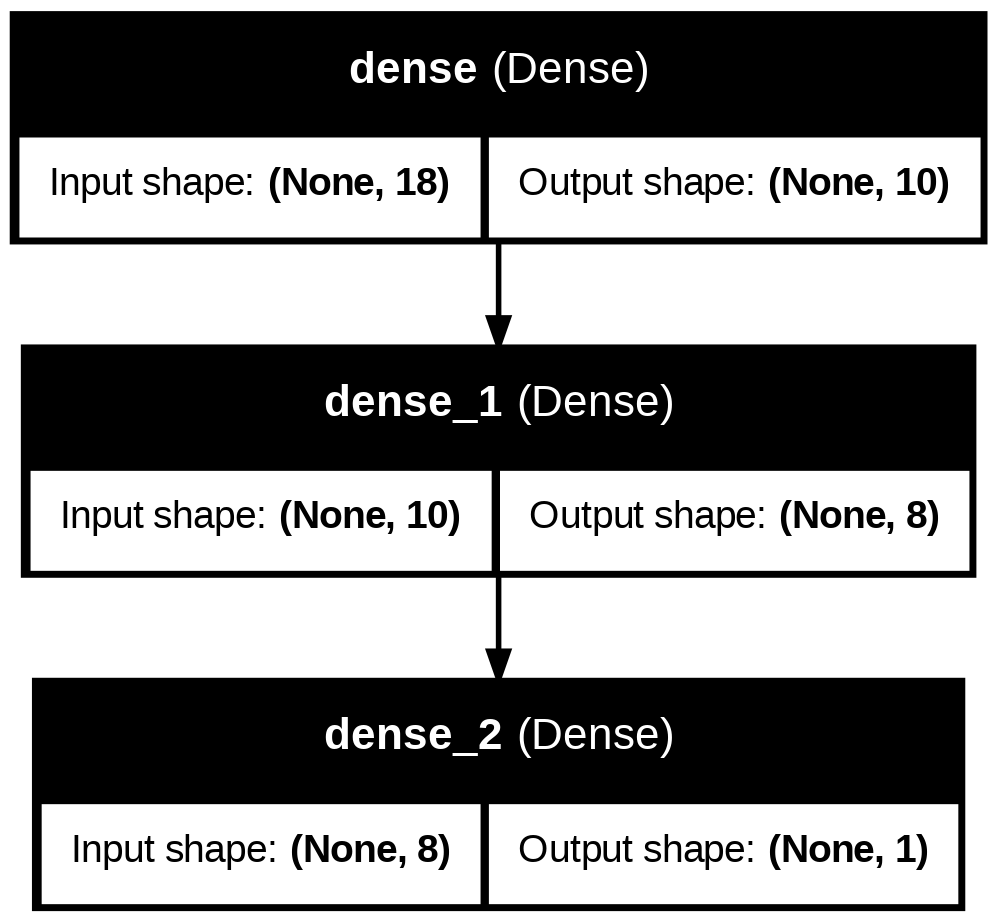

In [ ]:
# Plot the model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

### **<font color = "purple">Model Fitting</font>**

In [ ]:
history = model.fit(X_train, y_train, epochs=150, validation_split=0.25)

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2325 - loss: 3.2313 - val_accuracy: 0.2057 - val_loss: 2.4853
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2733 - loss: 2.1143 - val_accuracy: 0.2057 - val_loss: 1.6773
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2619 - loss: 1.4380 - val_accuracy: 0.2057 - val_loss: 1.0800
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2428 - loss: 0.9689 - val_accuracy: 0.5106 - val_loss: 0.7514
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6525 - loss: 0.6852 - val_accuracy: 0.7305 - val_loss: 0.6335
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6780 - loss: 0.6708 - val_accuracy: 0.7660 - val_loss: 0.5972
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7274 - loss: 0.6154 - val_accuracy: 0.7872 - val_loss: 0.5842
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7573 - loss: 0.5758 - val_accuracy: 0.7872 - 

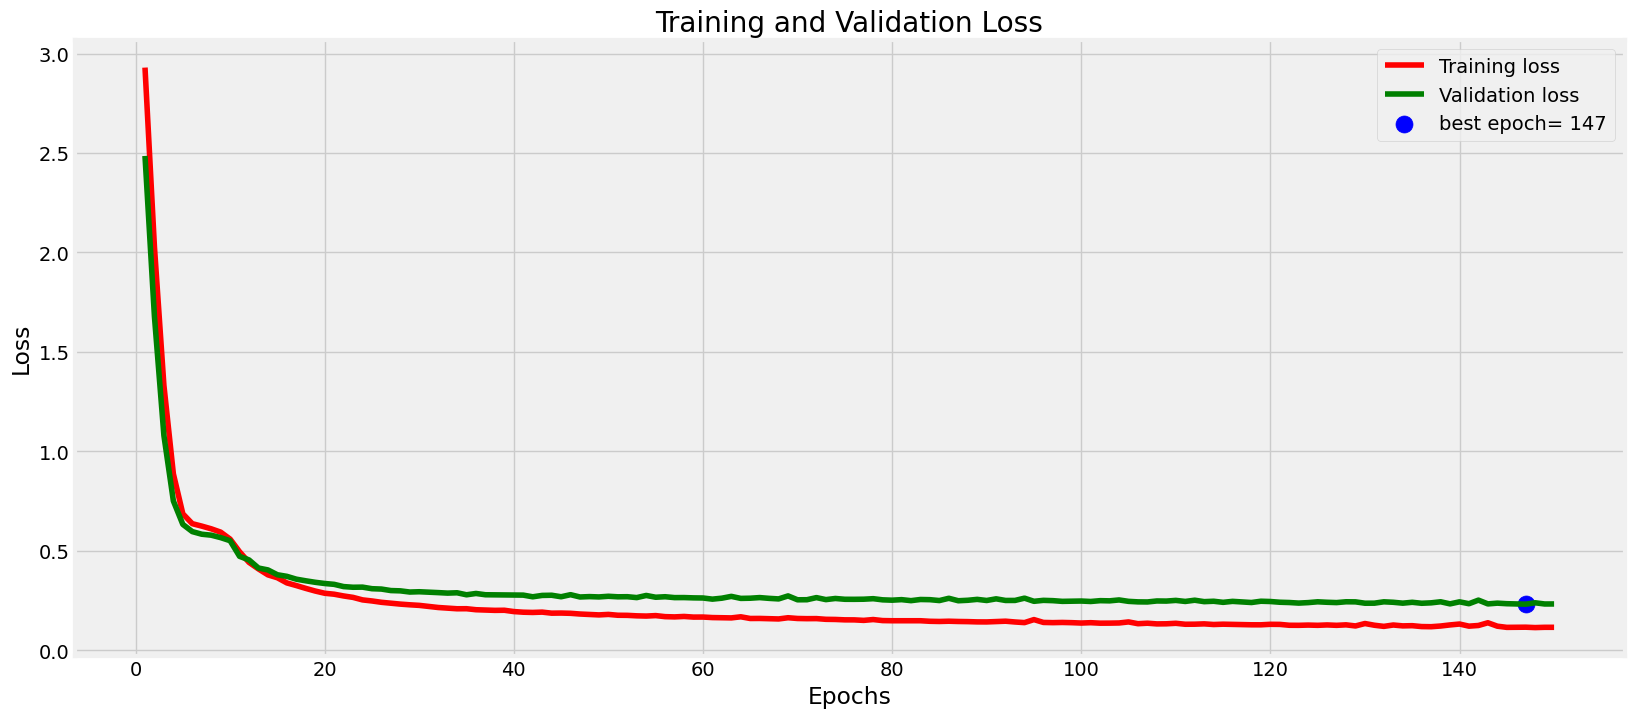

In [ ]:
# Define needed variables
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = [i+1 for i in range(len(tr_loss))]
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
acc = history.history['accuracy']

acc_loss_df = pd.DataFrame({"Accuracy" : acc,
                            "Loss" : tr_loss,
                            "Epoch" : Epochs})

acc_loss_df.style.bar(color = '#84A9AC',
                      subset = ['Accuracy','Loss'])

,Accuracy,Loss,Epoch
0,0.263658,2.929247,1
1,0.263658,2.026918,2
2,0.263658,1.331735,3
3,0.270784,0.887710,4
4,0.650831,0.686715,5
5,0.700713,0.637082,6
6,0.717340,0.624911,7
7,0.736342,0.611328,8
8,0.743468,0.594621,9
9,0.755344,0.559701,10


### **<font color = "purple">Prediction</font>**

In [ ]:
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
X_test.head(5)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,contry_of_res,result,relation
496,0,0,0,1,0,0,0,1,0,1,46.0,1,5,0,0,66,3.0,4
165,1,0,0,0,1,0,1,1,0,1,42.0,1,0,0,0,57,5.0,4
55,1,1,1,1,1,1,0,1,1,1,30.0,0,0,0,0,17,9.0,4
583,1,1,0,1,1,1,0,1,1,0,40.0,0,1,1,1,63,7.0,3
609,1,0,0,1,0,0,1,1,0,0,25.0,1,0,0,0,29,4.0,4


In [ ]:
y_pred = (y_pred > 0.5)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

cm = confusion_matrix(y_test, y_pred)
cm

array([[83,  9],
       [ 7, 42]])

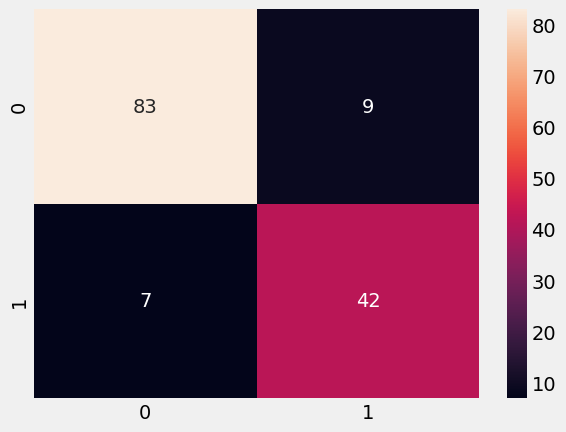

In [ ]:
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

# إعادة بناء y_true و y_pred تلقائيًا
y_true = [0] * (TN + FP) + [1] * (FN + TP)
y_pred = [0] * TN + [1] * FP + [0] * FN + [1] * TP

# التأكد من أن القيم ثنائية
y_act = [int(val) for val in y_true]
y_hat = [int(val) for val in y_pred]

# حساب المقاييس
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)#توقعات الموديل الصحيحة
recall = recall_score(y_true, y_pred)#القيم هي أصلا صحيحة
f1 = f1_score(y_true, y_pred)

# طباعة النتائج
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.89
Precision: 0.82
Recall: 0.86
F1-Score: 0.84


In [ ]:
model.save('autism_model.h5')


In [ ]:
from tensorflow.keras.models import load_model

# تحميل النموذج
loaded_model = load_model('autism_model.h5')

# عرض ملخص النموذج للتأكد
loaded_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             190 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              88 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 287 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
#x= pd.DataFrame([0,	0,	0,	1,	0,	0,	0,	1,	0,	1,	46.0,	1,	5,	0,	0,	66,	3.0,	4], index=X.columns)

y_pred = model.predict(X_test[2:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [ ]:
y_pred == y_test[2:3]

array([[False]])

In [ ]:
print(y_pred)

[[0.9957528]]


In [ ]:
print(y_test[2:3])

[1]


In [ ]:
y_test

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1])